<a href="https://colab.research.google.com/github/m16no/Aplikasi-Login/blob/main/Job_Skill_Recommendation_NotebookSementara_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Job Skill Recommendation System
Notebook ini mencakup seluruh alur kerja dari awal hingga akhir:

1. **Data Pipeline** : pembersihan, eksplorasi, dan feature engineering dataset
2. **Model Development** : training model deep learning dengan TensorFlow
3. **Deployment** : serving model via FastAPI dan integrasi Generative AI

---
**Dataset:** `job_recommendation_dataset.csv` (50.000 baris, 7 kolom)  
**Target:** Multi-label classification — prediksi skill yang dibutuhkan berdasarkan konteks pekerjaan

---
## Bagian 1 Setup Environment

Install semua dependensi yang dibutuhkan sepanjang pipeline.

In [ ]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn fastapi uvicorn nest-asyncio pyngrok

### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import json
import os
from collections import Counter
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

warnings.filterwarnings('ignore')

In [ ]:
import tensorflow as tf
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer


---
## Bagian 2  Konfigurasi

Akan ditentukan path dataset dan direktori output sebelum menjalankan pipeline.

In [ ]:
INPUT_PATH = "job_recommendation_dataset (1).csv"
OUTPUT_DIR = "output_pipeline"

os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## Bagian 3 Data Pipeline

Sebelum membangun model, baiknya dataset perlu melewati serangkaian tahap preprocessing agar bersih dan konsisten.

| Tahap | Deskripsi |
|-------|-----------|
| **Data Gathering & Assessment** | Memahami kondisi awal dataset |
| **Data Cleaning** | Menghapus duplikat, merapikan format teks |
| **EDA** | Menjawab pertanyaan bisnis dari pola data |
| **Visualisasi** | Mengubah angka menjadi insight visual |

### 3.1  Data Gathering & Assessment

Memahami struktur, tipe data, dan kondisi awal dataset sebelum melakukan perubahan apapun.

In [ ]:
# Load dataset
df_raw = pd.read_csv(INPUT_PATH)
df = df_raw.copy()
print("Informasi Umum Dataset")
print(f"Jumlah baris    : {df.shape[0]:,}")
print(f"Jumlah kolom    : {df.shape[1]}")

print("\nTipe data setiap kolom:")
print(df.dtypes)


Informasi Umum Dataset
Jumlah baris    : 50,000
Jumlah kolom    : 7

Tipe data setiap kolom:
Job Title            object
Company              object
Location             object
Experience Level     object
Salary              float64
Industry             object
Required Skills      object
dtype: object


In [ ]:
#Gambaran Umum Dataset
df.head()


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


In [ ]:
print("Statistik deskriptif kolom numerik:")
df.describe()


Statistik deskriptif kolom numerik:


,Salary
count,50000.000000
mean,95145.100000
std,31782.635648
min,40000.000000
25%,68000.000000
50%,95000.000000
75%,123000.000000
max,150000.000000


In [ ]:
print("Jumlah missing values per kolom:")
missing = df.isnull().sum()
pd.DataFrame(missing)


Jumlah missing values per kolom:


,0
Job Title,0
Company,0
Location,0
Experience Level,0
Salary,0
Industry,0
Required Skills,0


In [ ]:
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

print("\nJumlah nilai unik per kolom:")
unique_df = pd.DataFrame({
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Sample Values': [df[c].unique()[:3].tolist() for c in df.columns]
}, index=df.columns)
unique_df


Jumlah baris duplikat: 0

Jumlah nilai unik per kolom:


,Unique Values,Sample Values
Job Title,639,"[Early years teacher, Counselling psychologist..."
Company,37022,"[Richardson Ltd, Ramos, Santiago and Stewart, ..."
Location,7,"[Sydney, San Francisco, New York]"
Experience Level,3,"[Senior Level, Mid Level, Entry Level]"
Salary,111,"[87000.0, 50000.0, 77000.0]"
Industry,7,"[Healthcare, Marketing, Software]"
Required Skills,1559,"[Pharmaceuticals, Google Ads, SEO, Content Wri..."


### 3.2  Data Cleaning

Walaupun dataset tidak memiliki missing values, ada beberapa masalah tersembunyi yang perlu diatasi:

| Masalah | Dampak | Solusi |
|---------|--------|--------|
| Whitespace tersembunyi | `"Python "` ≠ `"Python"` | `.str.strip()` |
| Kapitalisasi tidak konsisten | Komparasi string gagal | `.str.title()` |
| Format skills tidak rapi | Parsing skill error | Trim per-skill |
| Outlier salary | Bias distribusi | IQR check |

In [ ]:
#Hapus duplikat
df = df.drop_duplicates()

In [ ]:
#Memastikan tidak ada whitespace pada data kategorik
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()
print(f"Strip whitespace pada {len(str_cols)} kolom teks: {list(str_cols)}")


Strip whitespace pada 6 kolom teks: ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']


In [ ]:
#Standardisasi kapitalisasi kolom kategorikal (Kapitalisasi huruf pertama tiap kata)
categorical_cols = ['Experience Level', 'Industry', 'Location']
for col in categorical_cols:
    df[col] = df[col].str.title()
print(f"Standardisasi kapitalisasi: {categorical_cols}")


Standardisasi kapitalisasi: ['Experience Level', 'Industry', 'Location']


In [ ]:
# Bersihkan kolom Required Skills (trim tiap skill individual)
df['Required Skills'] = df['Required Skills'].apply(
    lambda x: ', '.join([s.strip() for s in x.split(',') if s.strip()])
)


Melihat outlier fitur salary

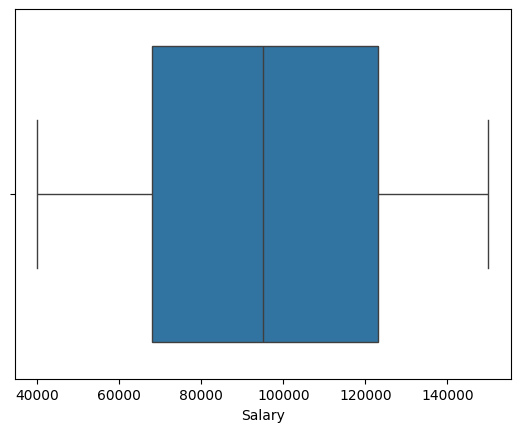

In [ ]:
sns.boxplot(x=df['Salary'])
plt.show()

Perhatikan, tidak ada outlier yang ditemukan

Selanjutnya karena kita sudah melakukan sesi cleaning. kita simpan dataset yang sudah bersih

In [ ]:
df_clean = df.copy()
df_clean

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"
...,...,...,...,...,...,...,...
49995,Veterinary surgeon,"Schultz, Hutchinson and Scott",Bangalore,Senior Level,112000.0,Education,EdTech
49996,Mental health nurse,Garcia-Thompson,New York,Entry Level,150000.0,Software,"Java, Machine Learning, React, AWS"
49997,Field trials officer,Fernandez Group,San Francisco,Mid Level,76000.0,Manufacturing,"Production Planning, Quality Control"
49998,Geographical information systems officer,"Thompson, Jarvis and Campbell",Toronto,Mid Level,137000.0,Marketing,"Social Media, Google Ads, Content Writing"


### 3.3  Exploratory Data Analysis (EDA)

EDA menjawab pertanyaan bisnis utama:
1. Industri apa yang paling banyak membuka lowongan?
2. Skill apa yang paling banyak dibutuhkan?
3. Apakah salary berbeda signifikan antar experience level?
4. Berapa banyak skill yang biasanya dibutuhkan per job?

In [ ]:
#Distribusi per Industry
print("Distribusi Job per Industry:")
industry_counts = df['Industry'].value_counts()
display(industry_counts.to_frame())


Distribusi Job per Industry:


,count
Industry,
Software,7302
Manufacturing,7169
Marketing,7158
Education,7144
Retail,7106
Healthcare,7104
Finance,7017


In [ ]:
#Distribusi Experience Level
print("Distribusi Experience Level:")
exp_counts = df['Experience Level'].value_counts()
display(exp_counts.to_frame())


Distribusi Experience Level:


,count
Experience Level,
Mid Level,16739
Senior Level,16658
Entry Level,16603


In [ ]:
#Salary per Experience Level
print("Statistik Salary per Experience Level:")
salary_by_exp = df.groupby('Experience Level')['Salary'].agg(['mean','median','std','min','max']).round(0)
display(salary_by_exp)


Statistik Salary per Experience Level:


,mean,median,std,min,max
Experience Level,,,,,
Entry Level,95460.0,95000.0,31803.0,40000.0,150000.0
Mid Level,95015.0,95000.0,31707.0,40000.0,150000.0
Senior Level,94962.0,95000.0,31838.0,40000.0,150000.0


In [ ]:
#Analisis Skills
all_skills_list = [s.strip() for skills in df['Required Skills'].str.split(',') for s in skills]
skill_counts = Counter(all_skills_list)
top_skills = pd.DataFrame(skill_counts.most_common(), columns=['Skill', 'Count'])

print(f"Total skill unik: {len(set(all_skills_list))}")
print("\nTop 15 Skill Paling Dibutuhkan:")
display(top_skills.head(15).reset_index(drop=True))


Total skill unik: 29

Top 15 Skill Paling Dibutuhkan:


,Skill,Count
0,Python,6173
1,SQL,6104
2,Production Planning,5442
3,Quality Control,5407
4,Merchandising,5405
5,Supply Chain,5401
6,Customer Service,5360
7,Sales,5317
8,Teaching,4518
9,EdTech,4492


In [ ]:
#Distribusi jumlah skill per job
df['Skill_Count'] = df['Required Skills'].str.split(',').apply(len)
print("Jumlah skill per job posting:")
display(df['Skill_Count'].value_counts().sort_index().to_frame(name='Jumlah Job'))


Jumlah skill per job posting:


,Jumlah Job
Skill_Count,
1,12431
2,12270
3,16323
4,8976


In [ ]:
#Rata-rata salary per industry
print("Rata-rata Salary per Industry:")
salary_by_ind = df.groupby('Industry')['Salary'].agg(['mean','median']).round(0).sort_values('mean', ascending=False)
display(salary_by_ind)


Rata-rata Salary per Industry:


,mean,median
Industry,,
Software,95606.0,95000.0
Healthcare,95455.0,96000.0
Marketing,95204.0,96000.0
Retail,95197.0,95000.0
Education,95191.0,95000.0
Finance,94944.0,95000.0
Manufacturing,94409.0,94000.0


### 3.4  Visualisasi Data

Visualisasi mengubah angka-angka dari EDA menjadi insight yang mudah dipahami.

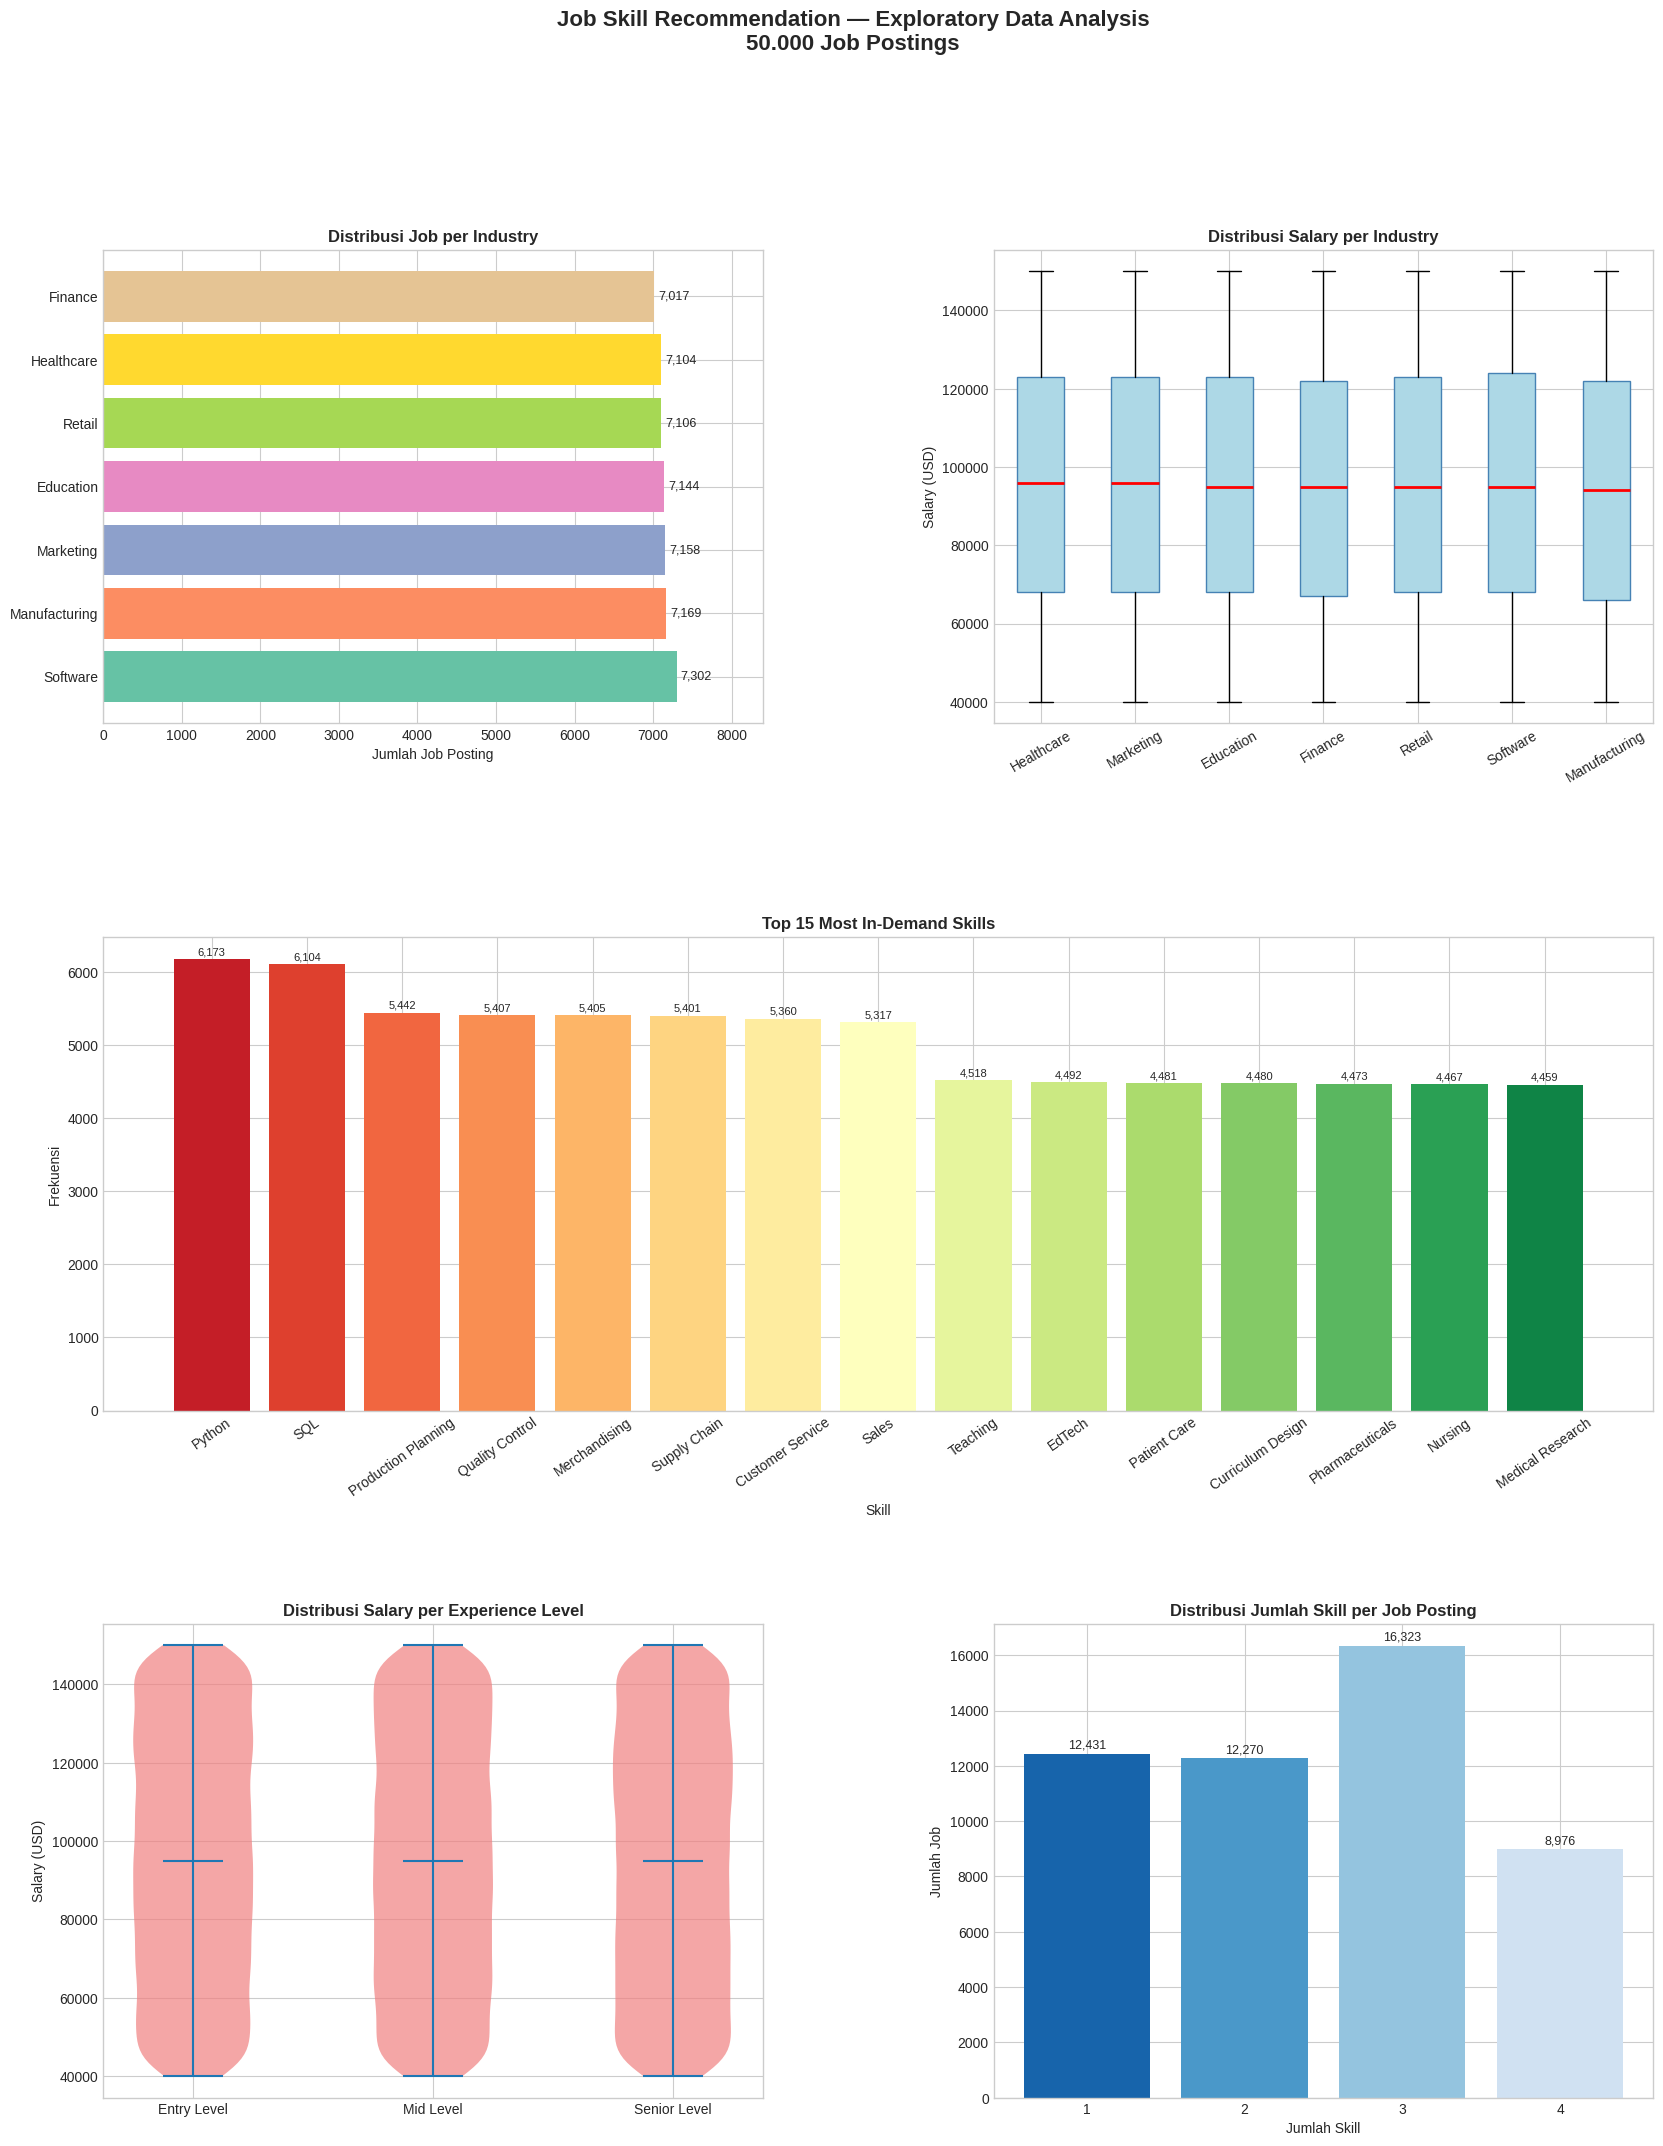

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle('Job Skill Recommendation — Exploratory Data Analysis\n50.000 Job Postings',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Distribusi Industry
ax1 = fig.add_subplot(gs[0, 0])
colors = sns.color_palette('Set2', len(industry_counts))
bars = ax1.barh(industry_counts.index, industry_counts.values, color=colors)
ax1.set_title('Distribusi Job per Industry', fontweight='bold', fontsize=12)
ax1.set_xlabel('Jumlah Job Posting')
for bar, val in zip(bars, industry_counts.values):
    ax1.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlim(0, max(industry_counts.values) * 1.15)

# Plot 2: Boxplot Salary per Industry
ax2 = fig.add_subplot(gs[0, 1])
industry_order = df.groupby('Industry')['Salary'].median().sort_values(ascending=False).index
bp = ax2.boxplot(
    [df[df['Industry'] == ind]['Salary'].values for ind in industry_order],
    labels=industry_order, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='steelblue'),
    medianprops=dict(color='red', linewidth=2)
)
ax2.set_title('Distribusi Salary per Industry', fontweight='bold', fontsize=12)
ax2.set_ylabel('Salary (USD)')
ax2.tick_params(axis='x', rotation=30)

# Plot 3: Top 15 Skills
ax3 = fig.add_subplot(gs[1, :])
top15 = top_skills.head(15)
bars3 = ax3.bar(top15['Skill'], top15['Count'], color=sns.color_palette('RdYlGn', 15))
ax3.set_title('Top 15 Most In-Demand Skills', fontweight='bold', fontsize=12)
ax3.set_xlabel('Skill')
ax3.set_ylabel('Frekuensi')
ax3.tick_params(axis='x', rotation=35)
for bar, val in zip(bars3, top15['Count']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# Plot 4: Violin Salary per Experience Level
ax4 = fig.add_subplot(gs[2, 0])
exp_order = ['Entry Level', 'Mid Level', 'Senior Level']
exp_data  = [df[df['Experience Level'] == lvl]['Salary'].values for lvl in exp_order]
vp = ax4.violinplot(exp_data, positions=[1, 2, 3], showmedians=True)
ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(exp_order)
ax4.set_title('Distribusi Salary per Experience Level', fontweight='bold', fontsize=12)
ax4.set_ylabel('Salary (USD)')
for pc in vp['bodies']:
    pc.set_facecolor('lightcoral'); pc.set_alpha(0.7)

# Plot 5: Distribusi Skill Count
ax5 = fig.add_subplot(gs[2, 1])
sc_dist = df['Skill_Count'].value_counts().sort_index()
ax5.bar(sc_dist.index.astype(str), sc_dist.values, color=sns.color_palette('Blues_r', len(sc_dist)))
ax5.set_title('Distribusi Jumlah Skill per Job Posting', fontweight='bold', fontsize=12)
ax5.set_xlabel('Jumlah Skill')
ax5.set_ylabel('Jumlah Job')
for i, (x, val) in enumerate(zip(sc_dist.index, sc_dist.values)):
    ax5.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.savefig(os.path.join(OUTPUT_DIR, "eda_visualization.png"), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 — Data Dictionary

Dokumentasi resmi kolom-kolom dalam dataset bersih yang menjadi input pipeline model.

In [ ]:
data_dict = {
    "Dataset"   : "Job Skill Recommendation — Clean",
    "Total Rows": df_clean.shape[0],
    "Total Columns": df_clean.shape[1],
    "Deskripsi" : "Dataset hasil cleaning dan preprocessing, siap digunakan untuk training model deep learning.",
    "columns": {
        "Job Title"       : {"type": "string", "desc": "Judul pekerjaan (639 nilai unik)"},
        "Company"         : {"type": "string", "desc": "Nama perusahaan"},
        "Location"        : {"type": "string", "desc": "Kota lokasi kerja. 7 kota: Bangalore, Berlin, London, New York, San Francisco, Sydney, Toronto."},
        "Industry"        : {"type": "string", "desc": "Industri perusahaan. 7 industri: Education, Finance, Healthcare, Manufacturing, Marketing, Retail, Software."},
        "Experience Level": {"type": "string", "desc": "Level pengalaman kerja: Entry Level / Mid Level / Senior Level."},
        "Salary"          : {"type": "float",  "desc": "Gaji tahunan dalam USD. Tidak ada outlier signifikan berdasarkan IQR check."},
        "Required Skills" : {"type": "string", "desc": "Daftar skill yang dibutuhkan, dipisahkan koma. Total 29 skill unik di seluruh dataset."},
    },
    "model_info": {
        "task"            : "Multi-Label Classification",
        "model_type"      : "Bidirectional LSTM + Custom Attention Layer (TensorFlow)",
        "input_type"      : "Teks: gabungan Job Title + Industry + Experience Level, di-clean lalu di-vektorisasi oleh TextVectorization layer",
        "output_labels"   : "29 label skill binary, di-encode dengan MultiLabelBinarizer (threshold prediksi = 0.5)",
        "train_test_split": "80% train / 20% test, random_state=42",
        "saved_model"     : "skill_recommendation_model.keras"
    }
}

dict_path = os.path.join(OUTPUT_DIR, "data_dictionary.json")
with open(dict_path, 'w', encoding='utf-8') as f:
    json.dump(data_dict, f, indent=2, ensure_ascii=False)

print("Data dictionary tersimpat di:", dict_path)


Data dictionary tersimpat di: output_pipeline/data_dictionary.json


### Ringkasan Pipeline

In [ ]:
print("=" * 60)
print(" RINGKASAN PIPELINE")
print("=" * 60)
print(f"INPUT  : job_recommendation_dataset.csv")
print(f"         {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"")
print(f"PROSES :")
print(f"  1. Data Gathering & Assessment")
print(f"  2. Data Cleaning (duplikat, whitespace, kapitalisasi)")
print(f"  3. EDA (distribusi, skill analysis, salary)")
print(f"  4. Visualisasi (6 chart)")
print(f"")
print(f"OUTPUT : output_pipeline/")
print(f"  data_dictionary.json    - Dokumentasi kolom dataset bersih")
print(f"  eda_visualization.png   - 6 chart EDA")
print(f"")
print(f"DATASET BERSIH (df_clean):")
print(f"  Baris : {df_clean.shape[0]:,}")
print(f"  Kolom : {df_clean.shape[1]}")
print(f"  Siap digunakan sebagai input model di Bagian 4")
print("=" * 60)


 RINGKASAN PIPELINE
INPUT  : job_recommendation_dataset.csv
         50,000 baris x 7 kolom

PROSES :
  1. Data Gathering & Assessment
  2. Data Cleaning (duplikat, whitespace, kapitalisasi)
  3. EDA (distribusi, skill analysis, salary)
  4. Visualisasi (6 chart)

OUTPUT : output_pipeline/
  data_dictionary.json    - Dokumentasi kolom dataset bersih
  eda_visualization.png   - 6 chart EDA

DATASET BERSIH (df_clean):
  Baris : 50,000
  Kolom : 7
  Siap digunakan sebagai input model di Bagian 4


---
## Bagian 4  Persiapan Input Model

Data pipeline di atas menghasilkan dataset bersih. Bagian ini mempersiapkan fitur teks (`text`) untuk digunakan oleh model deep learning

Kolom `text` dibentuk dengan menggabungkan Job Title, Industry, dan Experience Level, kemudian dibersihkan agar siap di-vektorisasi.

### Menggabungkan Fitur Teks

In [ ]:
# penggabungan feature
df_fix = df_clean.copy()
df_fix['text'] = (
    df_fix['Job Title'].astype(str) + ' ' +
    df_fix['Industry'].astype(str) + ' ' +
    df_fix['Experience Level'].astype(str)
)


### Pembersihan Teks

In [ ]:
#cleaning text

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df_fix['text'] = df_fix['text'].apply(clean_text)

### Preprocessing Label Skill (MultiLabelBinarizer)

In [ ]:
#Preprocessing Label Skill

df_fix['Required Skills'] = df_fix['Required Skills'].apply(
    lambda x: [skill.strip() for skill in str(x).split(',')]
)

mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df_fix['Required Skills'])

print('Jumlah skill unik:', len(mlb.classes_))
print(mlb.classes_[:20])


Jumlah skill unik: 29
['AWS' 'C++' 'Content Writing' 'Curriculum Design' 'Customer Service'
 'EdTech' 'Excel' 'Financial Modeling' 'Google Ads' 'Java'
 'Machine Learning' 'Market Research' 'Medical Research' 'Merchandising'
 'Nursing' 'Patient Care' 'Pharmaceuticals' 'Production Planning' 'Python'
 'Quality Control']


---
## Bagian 5  Model Development

Tahap ini membangun model deep learning untuk multi-label classification.

### 5.1  Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_fix['text'],
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(40000,)
(10000,)


### 5.2  Text Vectorization

In [ ]:
max_tokens = 20000
max_len = 50

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=max_len
)

vectorizer.adapt(X_train)

### 5.3  Convert ke TensorFlow Dataset

In [ ]:
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_dataset = val_dataset.batch(batch_size)

### 5.4  Custom Attention Layer

In [ ]:
class AttentionLayer(tf.keras.layers.Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def call(self, inputs):

        attention_weights = tf.nn.softmax(inputs, axis=1)

        context_vector = attention_weights * inputs

        context_vector = tf.reduce_sum(
            context_vector,
            axis=1
        )

        return context_vector

    def get_config(self):

        config = super().get_config()

        return config

### 5.5  Arsitektur Model

In [ ]:
inputs = tf.keras.Input(shape=(1,), dtype=tf.string)

x = vectorizer(inputs)

x = tf.keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=128
)(x)

x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(
        64,
        return_sequences=True
    )
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

x = AttentionLayer()(x)

x = tf.keras.layers.Dense(128, activation='relu')(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    y.shape[1],
    activation='sigmoid'
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │             0 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,679,069 (10.22 MB)

 Trainable params: 2,679,069 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

### 5.6 Loss Function & Optimizer

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

### 5.7 Metrics

In [ ]:
train_acc_metric = tf.keras.metrics.BinaryAccuracy()
val_acc_metric = tf.keras.metrics.BinaryAccuracy()

### 5.8 TensorBoard Setup

In [ ]:
log_dir = 'logs'
summary_writer = tf.summary.create_file_writer(log_dir)

### 5.9 Custom Training Loop (tf.GradientTape)

Training loop manual memberikan kontrol penuh: gradient computation, weight update, logging ke TensorBoard, dan tracking metrik per epoch.

In [ ]:
epochs = 10

for epoch in range(epochs):

    print(f'\nEpoch {epoch+1}/{epochs}')


    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):

        with tf.GradientTape() as tape:

            logits = model(x_batch_train, training=True)

            loss_value = loss_fn(y_batch_train, logits)

        grads = tape.gradient(loss_value, model.trainable_weights)

        optimizer.apply_gradients(
            zip(grads, model.trainable_weights)
        )

        train_acc_metric.update_state(y_batch_train, logits)

        if step % 100 == 0:
            print(
                f'Step {step} - Loss: {loss_value.numpy():.4f}'
            )


    train_acc = train_acc_metric.result()

    print(f'Train Accuracy: {train_acc:.4f}')


    for x_batch_val, y_batch_val in val_dataset:

        val_logits = model(x_batch_val, training=False)

        val_acc_metric.update_state(y_batch_val, val_logits)

    val_acc = val_acc_metric.result()

    print(f'Validation Accuracy: {val_acc:.4f}')


    with summary_writer.as_default():

        tf.summary.scalar(
            'train_accuracy',
            train_acc,
            step=epoch
        )

        tf.summary.scalar(
            'validation_accuracy',
            val_acc,
            step=epoch
        )

    train_acc_metric.reset_state()
    val_acc_metric.reset_state()


Epoch 1/10
Step 0 - Loss: 0.6952
Step 100 - Loss: 0.3052
Step 200 - Loss: 0.2935
Step 300 - Loss: 0.1723
Step 400 - Loss: 0.1098
Step 500 - Loss: 0.1088
Step 600 - Loss: 0.1220
Train Accuracy: 0.9226
Validation Accuracy: 0.9351

Epoch 2/10
Step 0 - Loss: 0.1032
Step 100 - Loss: 0.0970
Step 200 - Loss: 0.1048
Step 300 - Loss: 0.0999
Step 400 - Loss: 0.1044
Step 500 - Loss: 0.1011
Step 600 - Loss: 0.0932
Train Accuracy: 0.9390
Validation Accuracy: 0.9370

Epoch 3/10
Step 0 - Loss: 0.1020
Step 100 - Loss: 0.0980
Step 200 - Loss: 0.1019
Step 300 - Loss: 0.1059
Step 400 - Loss: 0.1020
Step 500 - Loss: 0.1045
Step 600 - Loss: 0.1090
Train Accuracy: 0.9402
Validation Accuracy: 0.9389

Epoch 4/10
Step 0 - Loss: 0.1096
Step 100 - Loss: 0.0917
Step 200 - Loss: 0.1025
Step 300 - Loss: 0.0973
Step 400 - Loss: 0.0950
Step 500 - Loss: 0.1059
Step 600 - Loss: 0.1018
Train Accuracy: 0.9411


### 5.10 Visualisasi TensorBoard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs

---
## Bagian 6 Evaluasi Model

Evaluasi dilakukan pada data test menggunakan metrik akurasi biner. Threshold prediksi ditetapkan di 0.5 — jika probabilitas skill > 0.5, skill tersebut dianggap relevan.

In [ ]:
from sklearn.metrics import accuracy_score

X_test_tensor = tf.constant(X_test)

predictions = model.predict(X_test_tensor)

pred_binary = (predictions > 0.5).astype(int)

accuracy = accuracy_score(
    y_test.flatten(),
    pred_binary.flatten()
)

print("Accuracy:", accuracy)


### Inference Function

In [ ]:
def predict_skills(text):

    input_tensor = tf.constant([text])

    pred = model.predict(input_tensor)

    pred_binary = (pred > 0.5).astype(int)

    skills = mlb.inverse_transform(pred_binary)

    return skills


sample = 'ai engineer software senior'

result = predict_skills(sample)

print(result)

---
## Bagian 7 Simpan & Load Model

Model disimpan dalam format `.keras` agar bisa di-load ulang tanpa perlu training ulang.

### Simpan Model

In [ ]:
model.save('skill_recommendation_model.keras')

### Load Model

In [ ]:
loaded_model = tf.keras.models.load_model(
    'skill_recommendation_model.keras',
    custom_objects={
        'AttentionLayer': AttentionLayer
    }
)

---
## Bagian 8 Deployment dengan FastAPI

Model di-serve menggunakan FastAPI, sebuah framework Python yang ringan dan cepat untuk membangun REST API.

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import tensorflow as tf
import numpy as np

app = FastAPI()

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def call(self, inputs):
        attention_weights = tf.nn.softmax(inputs, axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

model = tf.keras.models.load_model(
    'skill_recommendation_model.keras',
    custom_objects={'AttentionLayer': AttentionLayer}
)

class InputData(BaseModel):
    text: str

@app.get('/')
def home():
    return {'message': 'Skill Recommendation API'}

@app.post('/predict')
def predict(data: InputData):
    prediction = model.predict([data.text])
    prediction = (prediction > 0.5).astype(int)
    return {
        'prediction': prediction.tolist()
    }


### Menjalankan Server FastAPI

In [ ]:
from pyngrok import ngrok
import nest_asyncio
import uvicorn
import os

nest_asyncio.apply()

# Simpan NGROK_TOKEN di environment variable, atau ganti langsung di sini
ngrok.set_auth_token(os.environ.get("NGROK_TOKEN", "YOUR_NGROK_TOKEN"))

public_url = ngrok.connect(8000)
print("Public URL:", public_url)

config = uvicorn.Config(
    app,
    host="0.0.0.0",
    port=8000
)

server = uvicorn.Server(config)

await server.serve()


---
## Bagian 9 Integrasi Generative AI (Gemini)

Setelah model memprediksi skill yang dibutuhkan, hasil prediksi tersebut diteruskan ke Google Gemini untuk menghasilkan rekomendasi karier yang lebih kaya — termasuk roadmap belajar, sertifikasi, dan saran pengembangan diri.

In [ ]:
!pip install -q google-generativeai

In [ ]:
#import library

import google.generativeai as genai

In [ ]:
#Configure API Key
# Simpan GEMINI_API_KEY di environment variable, atau ganti langsung di sini
genai.configure(api_key=os.environ.get("GEMINI_API_KEY", "YOUR_GEMINI_API_KEY"))


In [ ]:
#Load Gemini Model

model_gemini = genai.GenerativeModel(
    'gemini-1.5-flash'
)

In [ ]:
#Prediksi Skill dari Model

sample = 'AI Engineer Software Senior'

input_tensor = tf.constant([sample])

pred = model.predict(input_tensor)

pred_binary = (pred > 0.5).astype(int)

skills = mlb.inverse_transform(pred_binary)

predicted_skills = list(skills[0])

print(predicted_skills)

In [ ]:
#Hasil Prediksi

prompt = f'''
Saya ingin menjadi AI Engineer.

Skill saya saat ini:
{predicted_skills}

Berikan:
1. Roadmap belajar
2. Skill tambahan yang perlu dipelajari
3. Rekomendasi sertifikasi
4. Saran karier
'''

In [ ]:
#Generate Career Recommendation

response = model_gemini.generate_content(prompt)
print(response.text)
